In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/hope-speech-datasets/Finegrained_dev_data.csv
/kaggle/input/hope-speech-datasets/Finegrained_test_data_withoutlabel.csv
/kaggle/input/hope-speech-datasets/Finegrained_train_data.csv
/kaggle/input/hope-speech-datasets/train_CG.csv
/kaggle/input/hope-speech-datasets/dev_CG.csv
/kaggle/input/hope-speech-datasets/test_data_withoutlabelCG.csv


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q transformers datasets scikit-learn pandas torch accelerate


**Task-1 Coarse-Grained Hope Tone Classification**

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


2026-03-04 15:46:57.545754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772639217.694064      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772639217.736929      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772639218.108493      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772639218.108532      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772639218.108535      55 computation_placer.cc:177] computation placer alr

In [5]:
train_df = pd.read_csv("/kaggle/input/hope-speech-datasets/train_CG.csv")  
dev_df   = pd.read_csv("/kaggle/input/hope-speech-datasets/dev_CG.csv")    
test_df  = pd.read_csv("/kaggle/input/hope-speech-datasets/test_data_withoutlabelCG.csv")    

In [6]:
label_encoder = LabelEncoder()

train_df["label_enc"] = label_encoder.fit_transform(train_df["Label"])
dev_df["label_enc"]   = label_encoder.transform(dev_df["Label"])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)


['blended hope' 'discouraging hope' 'encouraging hope' 'uninvolved']


In [7]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["Text"],
        padding="max_length",
        truncation=True,
        max_length=192
    )


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [8]:
train_ds = Dataset.from_pandas(train_df[["Text", "label_enc"]])
dev_ds   = Dataset.from_pandas(dev_df[["Text", "label_enc"]])
test_ds  = Dataset.from_pandas(test_df[["Text"]])

train_ds = train_ds.map(tokenize, batched=True)
dev_ds   = dev_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_enc", "labels")
dev_ds   = dev_ds.rename_column("label_enc", "labels")

train_ds.set_format("torch")
dev_ds.set_format("torch")
test_ds.set_format("torch")


Map:   0%|          | 0/5991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1
    }


In [11]:
for param in model.roberta.parameters():
    param.requires_grad = False


In [12]:
training_args_stage1 = TrainingArguments(
    output_dir="/kaggle/working/task1_stage1",
    learning_rate=1e-5,              # LOWER
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,              # MORE
    warmup_ratio=0.1,                # IMPORTANT
    weight_decay=0.005,
    logging_steps=100,
    save_steps=500,
    do_eval=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)


In [13]:
trainer = Trainer(
    model=model,
    args=training_args_stage1,
    train_dataset=train_ds,
    eval_dataset=dev_ds
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
100,1.351900
200,1.291000
300,1.291600


TrainOutput(global_step=376, training_loss=1.3047659042033743, metrics={'train_runtime': 153.5756, 'train_samples_per_second': 78.02, 'train_steps_per_second': 2.448, 'total_flos': 1182244978916352.0, 'train_loss': 1.3047659042033743, 'epoch': 2.0})

In [14]:
for param in model.roberta.parameters():
    param.requires_grad = True


In [15]:
training_args_stage2 = TrainingArguments(
    output_dir="/kaggle/working/task1_stage2",
    learning_rate=1e-5,              # LOWER
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,              # MORE
    warmup_ratio=0.1,                # IMPORTANT
    weight_decay=0.005,
    logging_steps=100,
    save_steps=500,
    do_eval=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)


In [16]:
trainer = Trainer(
    model=model,
    args=training_args_stage2,
    train_dataset=train_ds,
    eval_dataset=dev_ds
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
100,1.265200
200,1.167500
300,1.054200
400,0.965600
500,0.940300
600,0.883400
700,0.861100
800,0.825600
900,0.819000
1000,0.787000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=1504, training_loss=0.8857116854571282, metrics={'train_runtime': 1235.6846, 'train_samples_per_second': 38.787, 'train_steps_per_second': 1.217, 'total_flos': 4728979915665408.0, 'train_loss': 0.8857116854571282, 'epoch': 8.0})

In [17]:
dev_preds = trainer.predict(dev_ds)
y_pred = np.argmax(dev_preds.predictions, axis=1)

print("Final Accuracy:", accuracy_score(dev_df["label_enc"], y_pred))
print("Final Macro-F1:", f1_score(dev_df["label_enc"], y_pred, average="macro"))

print(classification_report(
    dev_df["label_enc"],
    y_pred,
    target_names=label_encoder.classes_
))


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Final Accuracy: 0.6869158878504673
Final Macro-F1: 0.514374243159596
                   precision    recall  f1-score   support

     blended hope       0.42      0.31      0.36       191
discouraging hope       0.32      0.07      0.12       153
 encouraging hope       0.73      0.83      0.78       406
       uninvolved       0.73      0.89      0.80       534

         accuracy                           0.69      1284
        macro avg       0.55      0.53      0.51      1284
     weighted avg       0.64      0.69      0.65      1284



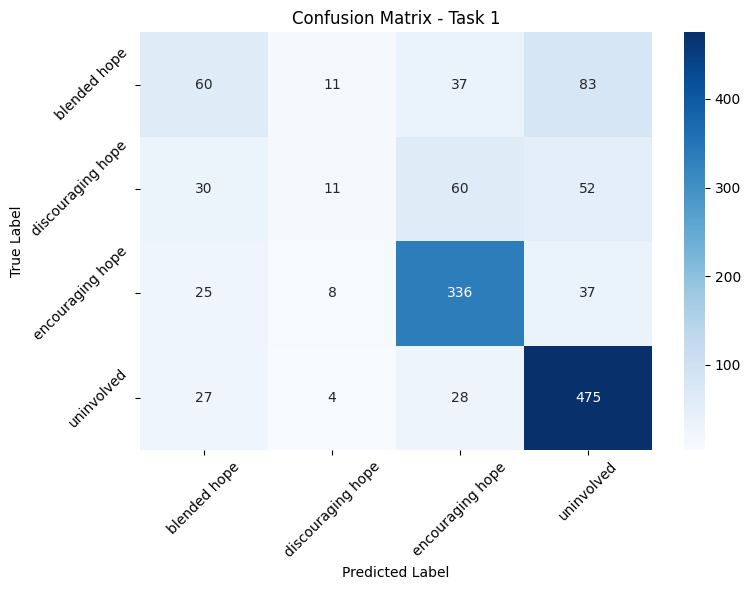

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True labels
y_true = dev_df["label_enc"].values

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Task 1")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
test_preds = trainer.predict(test_ds)
test_labels = np.argmax(test_preds.predictions, axis=1)

test_df["Label"] = label_encoder.inverse_transform(test_labels)

submission = test_df[["ID", "Label"]]
submission.to_csv("predictions.csv", index=False)

submission.head()


,ID,Label
0,Tu_CG_01,blended hope
1,Tu_CG_02,uninvolved
2,Tu_CG_03,blended hope
3,Tu_CG_04,uninvolved
4,Tu_CG_05,discouraging hope


In [20]:
!pip install -q transformers datasets scikit-learn accelerate


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


**Task-2 Fine-Grained Hope Type Classification**

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


In [22]:
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: True
GPU: Tesla T4


In [23]:
train_df = pd.read_csv("/kaggle/input/hope-speech-datasets/Finegrained_train_data.csv")
dev_df   = pd.read_csv("/kaggle/input/hope-speech-datasets/Finegrained_dev_data.csv")
test_df  = pd.read_csv("/kaggle/input/hope-speech-datasets/Finegrained_test_data_withoutlabel.csv")


In [24]:
label_encoder = LabelEncoder()

train_df["label_enc"] = label_encoder.fit_transform(train_df["Label"])
dev_df["label_enc"]   = label_encoder.transform(dev_df["Label"])

num_labels = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)


Classes: ['fading hope' 'hopelessness' 'inspiring hope' 'optimistic hope'
 'realistic hope']


In [25]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_enc"]),
    y=train_df["label_enc"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)


Class Weights: tensor([2.6992, 0.6798, 0.5642, 1.6763, 1.2664])


In [26]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["Text"],
        padding="max_length",
        truncation=True,
        max_length=192
    )


In [27]:
train_ds = Dataset.from_pandas(train_df[["Text", "label_enc"]])
dev_ds   = Dataset.from_pandas(dev_df[["Text", "label_enc"]])
test_ds  = Dataset.from_pandas(test_df[["Text"]])

train_ds = train_ds.map(tokenize, batched=True)
dev_ds   = dev_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_enc", "labels")
dev_ds   = dev_ds.rename_column("label_enc", "labels")

train_ds.set_format("torch")
dev_ds.set_format("torch")
test_ds.set_format("torch")


Map:   0%|          | 0/3185 [00:00<?, ? examples/s]

Map:   0%|          | 0/682 [00:00<?, ? examples/s]

Map:   0%|          | 0/683 [00:00<?, ? examples/s]

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("Model device:", next(model.parameters()).device)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model device: cpu


In [29]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }


In [31]:
import transformers
print(transformers.__version__)


4.57.1


In [32]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/task2_model",
    learning_rate=8e-6,               # EVEN LOWER
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=12,              # REQUIRED
    warmup_ratio=0.15,
    weight_decay=0.02,
    logging_steps=100,
    save_steps=500,
    do_eval=True,
    save_strategy="no",
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42
)


In [33]:
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    compute_metrics=compute_metrics
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
100,1.618900
200,1.609900
300,1.554400
400,1.434500
500,1.373800
600,1.299300
700,1.239000
800,1.191800
900,1.154300
1000,1.127400


TrainOutput(global_step=1200, training_loss=1.3174585660298666, metrics={'train_runtime': 966.4614, 'train_samples_per_second': 39.546, 'train_steps_per_second': 1.242, 'total_flos': 3771140776865280.0, 'train_loss': 1.3174585660298666, 'epoch': 12.0})

In [34]:
dev_preds = trainer.predict(dev_ds)
y_pred = np.argmax(dev_preds.predictions, axis=1)

print("Final Accuracy:", accuracy_score(dev_df["label_enc"], y_pred))
print("Final Macro-F1:", f1_score(dev_df["label_enc"], y_pred, average="macro"))

print(classification_report(
    dev_df["label_enc"],
    y_pred,
    target_names=label_encoder.classes_
))


Final Accuracy: 0.4442815249266862
Final Macro-F1: 0.3851774819900685
                 precision    recall  f1-score   support

    fading hope       0.18      0.45      0.26        51
   hopelessness       0.54      0.22      0.31       200
 inspiring hope       0.66      0.66      0.66       242
optimistic hope       0.35      0.68      0.47        81
 realistic hope       0.28      0.19      0.23       108

       accuracy                           0.44       682
      macro avg       0.40      0.44      0.39       682
   weighted avg       0.49      0.44      0.44       682



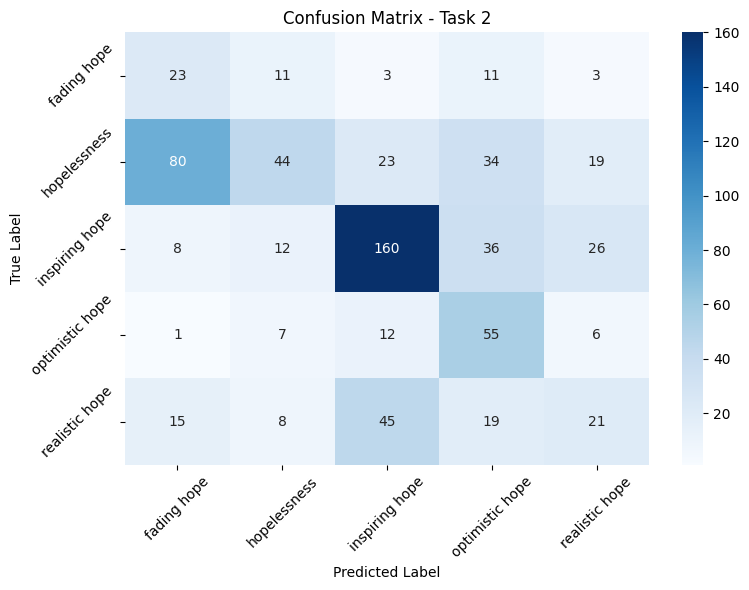

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True labels
y_true = dev_df["label_enc"].values

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Task 2")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
test_preds = trainer.predict(test_ds)
test_labels = np.argmax(test_preds.predictions, axis=1)

test_df["Label"] = label_encoder.inverse_transform(test_labels)

submission = test_df[["ID", "Label"]]
submission.to_csv("predictions1.csv", index=False)

submission.head()


,ID,Label
0,Tu_OLI_01,fading hope
1,Tu_OLI_02,fading hope
2,Tu_OLI_03,hopelessness
3,Tu_OLI_04,optimistic hope
4,Tu_OLI_05,optimistic hope
